In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (614, 13)

Column Names:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
# Fill missing categorical values with the most common value
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed"
]

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])


# Fill missing numerical values with the median
numerical_columns = [
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [5]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [6]:
# Convert categorical variables into numerical values
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)

# Convert Loan_Status into 0 and 1
df["Loan_Status"] = df["Loan_Status"].map({"N": 0, "Y": 1})

df.head()

,Loan_ID,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,LP001003,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,LP001005,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,LP001006,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,LP001008,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


In [7]:
# Separate input features (X) and target variable (y)

X = df.drop(columns=["Loan_Status", "Loan_ID"])
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (614, 14)
y shape: (614,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (491, 14)
Testing data: (123, 14)


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 123


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.8373983739837398
Model Accuracy (%): 83.73983739837398


Confusion Matrix:
[[24 14]
 [ 6 79]]


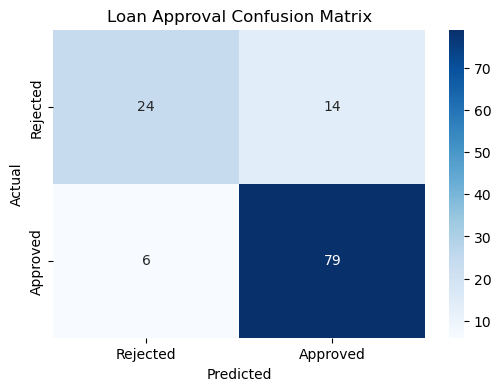

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Confusion Matrix")
plt.show()

In [13]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.80      0.63      0.71        38
    Approved       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123



In [14]:
# Create a new applicant

new_applicant = pd.DataFrame({
    "Gender": ["Male"],
    "Married": ["Yes"],
    "Dependents": ["0"],
    "Education": ["Graduate"],
    "Self_Employed": ["No"],
    "ApplicantIncome": [5000],
    "CoapplicantIncome": [2000],
    "LoanAmount": [150],
    "Loan_Amount_Term": [360],
    "Credit_History": [1.0],
    "Property_Area": ["Urban"]
})

print(new_applicant)

  Gender Married Dependents Education Self_Employed  ApplicantIncome  \
0   Male     Yes          0  Graduate            No             5000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0               2000         150               360             1.0   

  Property_Area  
0         Urban  


In [15]:
# Convert the new applicant into the same format as training data

new_applicant_encoded = pd.get_dummies(
    new_applicant,
    columns=[
        "Gender",
        "Married",
        "Dependents",
        "Education",
        "Self_Employed",
        "Property_Area"
    ],
    drop_first=True
)

# Make sure the columns are exactly the same as X
new_applicant_encoded = new_applicant_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

print("New applicant prepared successfully!")
print("Shape:", new_applicant_encoded.shape)

New applicant prepared successfully!
Shape: (1, 14)


In [16]:
# Predict loan approval for the new applicant

prediction = model.predict(new_applicant_encoded)[0]

if prediction == 1:
    print("🟢 Loan Approved")
else:
    print("🔴 Loan Rejected")

🟢 Loan Approved


In [17]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
0           ApplicantIncome    0.218810
4            Credit_History    0.211432
2                LoanAmount    0.196719
1         CoapplicantIncome    0.113846
3          Loan_Amount_Term    0.048915
12  Property_Area_Semiurban    0.031443
10   Education_Not Graduate    0.026607
6               Married_Yes    0.025855
13      Property_Area_Urban    0.024719
7              Dependents_1    0.023576
11        Self_Employed_Yes    0.022225
5               Gender_Male    0.020857
8              Dependents_2    0.019888
9             Dependents_3+    0.015108


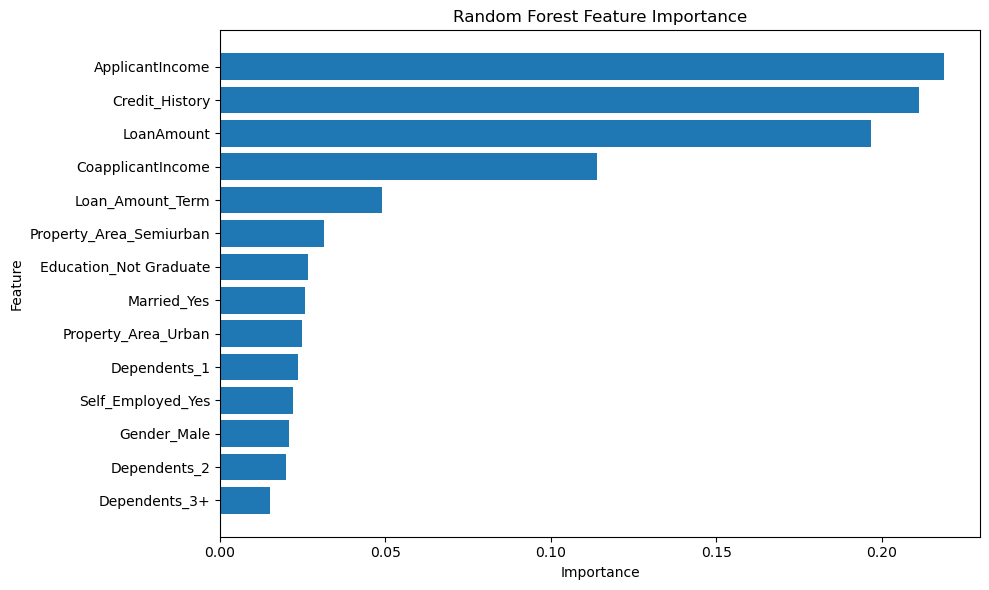

In [18]:
# Plot Feature Importance

plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

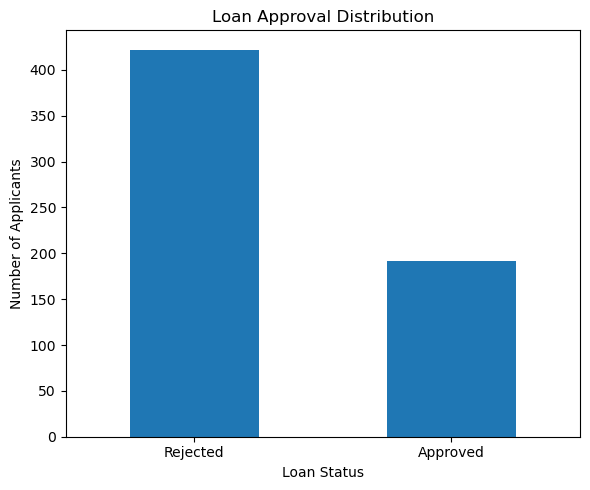

In [19]:
# Loan Status Distribution

plt.figure(figsize=(6, 5))

df["Loan_Status"].value_counts().plot(kind="bar")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.xticks(
    ticks=[0, 1],
    labels=["Rejected", "Approved"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [20]:
import joblib

# Save the trained Random Forest model
joblib.dump(model, "loan_approval_model.pkl")

# Save the feature columns used by the model
joblib.dump(list(X.columns), "loan_feature_columns.pkl")

print("Model saved successfully!")
print("Feature columns saved successfully!")

Model saved successfully!
Feature columns saved successfully!


In [21]:
import os

print("Model file exists:", os.path.exists("loan_approval_model.pkl"))
print("Feature file exists:", os.path.exists("loan_feature_columns.pkl"))

Model file exists: True
Feature file exists: True


In [22]:
# Reusable Loan Prediction Function

def predict_loan(
    gender,
    married,
    dependents,
    education,
    self_employed,
    applicant_income,
    coapplicant_income,
    loan_amount,
    loan_amount_term,
    credit_history,
    property_area
):
    
    # Create applicant DataFrame
    applicant = pd.DataFrame({
        "Gender": [gender],
        "Married": [married],
        "Dependents": [dependents],
        "Education": [education],
        "Self_Employed": [self_employed],
        "ApplicantIncome": [applicant_income],
        "CoapplicantIncome": [coapplicant_income],
        "LoanAmount": [loan_amount],
        "Loan_Amount_Term": [loan_amount_term],
        "Credit_History": [credit_history],
        "Property_Area": [property_area]
    })

    # Convert categorical variables
    applicant_encoded = pd.get_dummies(
        applicant,
        columns=[
            "Gender",
            "Married",
            "Dependents",
            "Education",
            "Self_Employed",
            "Property_Area"
        ],
        drop_first=True
    )

    # Match training features exactly
    applicant_encoded = applicant_encoded.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict
    prediction = model.predict(applicant_encoded)[0]

    if prediction == 1:
        return "Loan Approved"
    else:
        return "Loan Rejected"

In [23]:
result = predict_loan(
    gender="Male",
    married="Yes",
    dependents="0",
    education="Graduate",
    self_employed="No",
    applicant_income=5000,
    coapplicant_income=2000,
    loan_amount=150,
    loan_amount_term=360,
    credit_history=1.0,
    property_area="Urban"
)

print("Prediction:", result)

Prediction: Loan Approved
